# Value-at-Risk Backtesting

This notebook evaluates whether the volatility forecasts developed in the previous notebook, compared to regular GARCH, improve Value-at-Risk (VaR) estimation.

The baseline GARCH and regime-aware GARCH volatility forecasts are converted into one-day-ahead VaR forecasts and compared with realized returns during the out-of-sample period. Model performance is evaluated using VaR violations and statistical backtesting tests.

The objective is to determine whether incorporating HMM regime information improves risk forecasts compared with the standard GARCH benchmark.

## 1. Load Out-of-Sample Forecasts

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

project_root = Path.cwd().parent

forecast_path = (
    project_root
    / "data"
    / "processed"
    / "volatility_forecasts.csv"
)

volatility_forecasts = pd.read_csv(
    forecast_path,
    index_col="Date",
    parse_dates=True
)

volatility_forecasts.head()

,Baseline_GARCH,Regime_Adjustment,Regime_Aware_GARCH,Mu,Nu,Actual_Return
Date,,,,,,
2018-09-14,0.004737,1.006460,0.004768,0.00066,6.528264,0.000275
2018-09-17,0.004587,1.007362,0.004620,0.00066,6.528264,-0.005585
2018-09-18,0.004878,1.014775,0.004950,0.00066,6.528264,0.005355
2018-09-19,0.004950,1.015931,0.005029,0.00066,6.528264,0.001252
2018-09-20,0.004786,1.015937,0.004862,0.00066,6.528264,0.007810


## 2. Student-t Value-at-Risk

Value-at-Risk (VaR) gives a limit for how large a daily loss is expected to be under normal market conditions. A 99% one-day VaR means that we expect the return to fall below the VaR limit on about 1% of trading days. Since the GARCH models use a Student-t distribution a Student-t distribution is used when computing VaR. The Student-t distribution has heavier tails than the normal distribution which makes it better suited for large movements in financial returns. VaR is computed for each day using the one-day-ahead volatility forecasts from the previous notebook. The same method is used for both the baseline GARCH and the regime-aware GARCH. The resulting VaR tables are then compared directly.

### 2.1 VaR Specification

The one-day return is modeled as $r_{t+1} = \mu_t + z_{t+1} \sigma_{t+1|t}$ where $mu_t$ is the estimated mean return, $sigma_{t+1|t}$ is the one-day-ahead volatility forecast and $z_{t+1}$ follows a standardized Student-t distribution. For a 99% VaR the lower 1% quantile of the distribution is used and $VaR_{t+1|t}^{99\%}=\mu_t+ \sigma_{t+1|t}q_{0.01,\nu_t}$. A VaR violation is when the realized return is below the predicted VaR value and is $r_{t+1} < VaR_{t+1|t}$.

### 2.2 Standardized Student-t Quantile

To calculate 99% VaR we need the 1% quantile of the Student-t distribution. The GARCH volatility represents the conditional standard deviation of returns. Therefore, the Student-t distribution must have a variance of one before it is combined with the volatility forecast. A Student-t distribution with $v$ degrees of freedom has variance $\frac{v}{v-2}$. We therefore scale the Student-t quantile by $\sqrt{\frac{v-2}{v}}$ so that it is consistent with the volatility estimated by the GARCH model.

In [2]:
from scipy.stats import t

alpha = 0.01

nu = volatility_forecasts["Nu"]

student_t_quantile = t.ppf(alpha,df=nu)
standardized_t_quantile = (student_t_quantile * np.sqrt((nu - 2) / nu))

### 2.3 Baseline GARCH VaR

The baseline VaR forecast is calculated by combining the one-day-ahead GARCH volatility forecast with the standardized Student-t quantile $VaR_{t+1|t}^{GARCH} = \mu_t +\sigma_{t+1|t}^{GARCH} q_{0.01,v_t}$. Both the Student-t parameters and the volatility forecasts are based only on information available at the time of each forecast. 

In [3]:
baseline_var = (volatility_forecasts["Mu"] + volatility_forecasts["Baseline_GARCH"]* standardized_t_quantile)

volatility_forecasts["Baseline_VaR"] = baseline_var

volatility_forecasts[
    [
        "Mu",
        "Nu",
        "Baseline_GARCH",
        "Baseline_VaR",
        "Actual_Return"
    ]
].head()

,Mu,Nu,Baseline_GARCH,Baseline_VaR,Actual_Return
Date,,,,,
2018-09-14,0.00066,6.528264,0.004737,-0.011411,0.000275
2018-09-17,0.00066,6.528264,0.004587,-0.011027,-0.005585
2018-09-18,0.00066,6.528264,0.004878,-0.011768,0.005355
2018-09-19,0.00066,6.528264,0.004950,-0.011953,0.001252
2018-09-20,0.00066,6.528264,0.004786,-0.011534,0.007810


### 2.4 Regime-Aware GARCH VaR

The regime-aware VaR is calculated using the same Student-t distribution and parameters as the baseline model. The only difference is that the regime-aware volatility forecast is used instead of the baseline GARCH volatility. $VaR_{t+1|t}^{RA}= \mu_t + \sigma_{t+1|t}^{RA} q_{0.01,v_t}$. Using the same VaR specification for both models allows the effect of the HMM regime adjustment to be evaluated directly.

In [4]:
ra_adjusted_var = (volatility_forecasts["Mu"] + volatility_forecasts["Regime_Aware_GARCH"]* standardized_t_quantile)

volatility_forecasts["Regime_Aware_VaR"] = ra_adjusted_var

volatility_forecasts[
    [
        "Mu",
        "Nu",
        "Regime_Aware_GARCH",
        "Regime_Aware_VaR",
        "Actual_Return"
    ]
].head()

,Mu,Nu,Regime_Aware_GARCH,Regime_Aware_VaR,Actual_Return
Date,,,,,
2018-09-14,0.00066,6.528264,0.004768,-0.011489,0.000275
2018-09-17,0.00066,6.528264,0.004620,-0.011113,-0.005585
2018-09-18,0.00066,6.528264,0.004950,-0.011952,0.005355
2018-09-19,0.00066,6.528264,0.005029,-0.012154,0.001252
2018-09-20,0.00066,6.528264,0.004862,-0.011729,0.007810


## 3. VaR Violations

A VaR violation occurs when the realized return is lower than the predicted VaR threshold. For a 99% VaR model, violations are expected on approximately 1% of trading days.

The baseline and regime-aware VaR forecasts are compared with the same realized returns. This allows the number and frequency of violations to be evaluated for both models.

### 3.1 Identify Violations:

In [5]:
volatility_forecasts["Baseline_Violation"] = (volatility_forecasts["Actual_Return"] < volatility_forecasts["Baseline_VaR"])
volatility_forecasts["Regime_Aware_Violation"] = (volatility_forecasts["Actual_Return"]< volatility_forecasts["Regime_Aware_VaR"])

baseline_violations = volatility_forecasts["Baseline_Violation"].sum()
regime_violations = volatility_forecasts["Regime_Aware_Violation"].sum()

n_obs = len(volatility_forecasts)

baseline_violation_rate = baseline_violations / n_obs
regime_violation_rate = regime_violations / n_obs

print(f"Observations: {n_obs}")
print()

print(
    f"Baseline GARCH: "
    f"{baseline_violations} violations "
    f"({baseline_violation_rate:.2%})"
)

print(
    f"Regime-Aware GARCH: "
    f"{regime_violations} violations "
    f"({regime_violation_rate:.2%})"
)

print()
print("Expected violation rate for 99% VaR: 1.00%")

Observations: 2007

Baseline GARCH: 36 violations (1.79%)
Regime-Aware GARCH: 36 violations (1.79%)

Expected violation rate for 99% VaR: 1.00%


#### Discussion

Both models produce 36 VaR violations over 2006 observations with the violation rate of 1.79%. For a correctly calibrated 99% VaR model the expected violation rate is approximately 1%.

The higher observed violation rate suggests that both models may underestimate the risk of extreme negative returns. However, the number of violations alone is not enough to determine whether the models are correctly calibrated. This will be evaluated more formally using statistical backtests in Section 5.

Although both models have the same number of violations they may not necessarily occur on the same days. This will also be examined when comparing the models.

### 3.2 Visualization

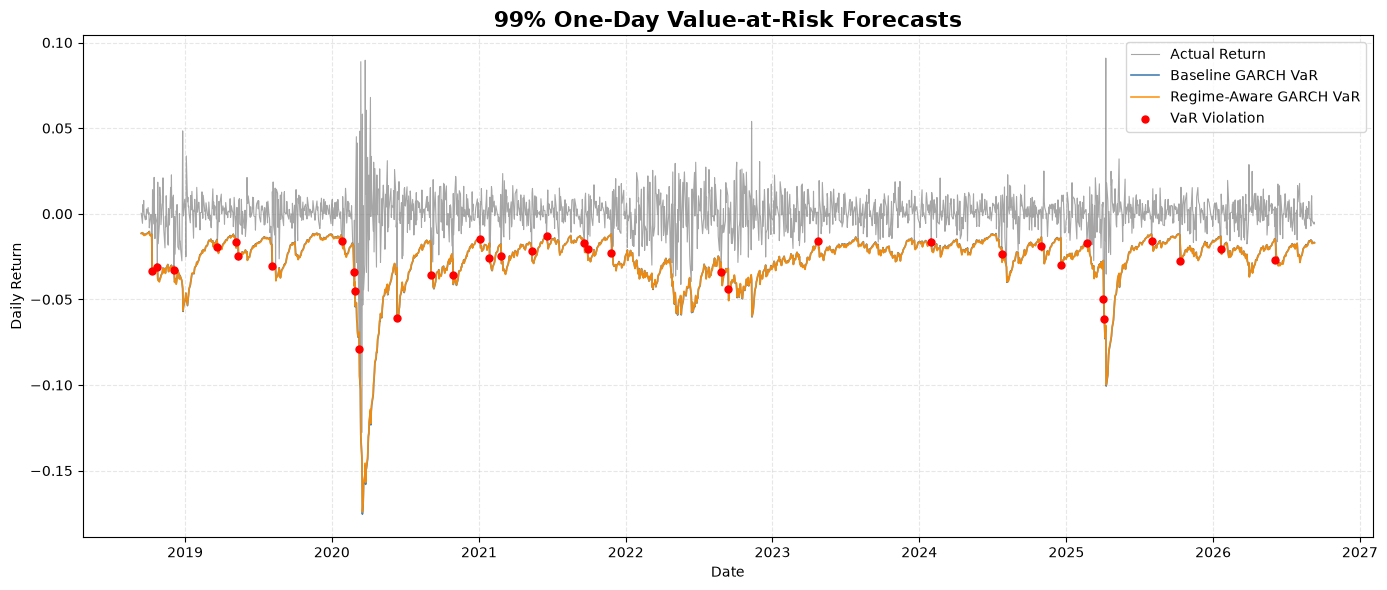

Identical violation days: True
Different classifications: 0


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    volatility_forecasts.index,
    volatility_forecasts["Actual_Return"],
    color="gray",
    linewidth=0.8,
    alpha=0.7,
    label="Actual Return"
)

ax.plot(
    volatility_forecasts.index,
    volatility_forecasts["Baseline_VaR"],
    color="steelblue",
    linewidth=1.2,
    label="Baseline GARCH VaR"
)

ax.plot(
    volatility_forecasts.index,
    volatility_forecasts["Regime_Aware_VaR"],
    color="darkorange",
    linewidth=1.2,
    alpha=0.9,
    label="Regime-Aware GARCH VaR"
)

baseline_mask = volatility_forecasts["Baseline_Violation"]

ax.scatter(
    volatility_forecasts.index[baseline_mask],
    volatility_forecasts.loc[baseline_mask, "Actual_Return"],
    color="red",
    s=25,
    zorder=5,
    label="VaR Violation"
)

ax.set_title(
    "99% One-Day Value-at-Risk Forecasts",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

same_violations = (
    volatility_forecasts["Baseline_Violation"]
    == volatility_forecasts["Regime_Aware_Violation"]
).all()

different_days = (
    volatility_forecasts["Baseline_Violation"]
    != volatility_forecasts["Regime_Aware_Violation"]
).sum()

print(f"Identical violation days: {same_violations}")
print(f"Different classifications: {different_days}")

#### Discussion

The VaR forecasts change over time as market volatility changes. During periods of high volatility, such as the market stress in 2020 during the outbreak of COVID-19, the VaR threshold becomes substantially more negative.

The baseline and regime-aware VaR forecasts remain very similar throughout the test period, this alligns with the relatively small regime adjustments found in the previous notebook. Both models produce 36 VaR violations and the violations occur on exactly the same days.

This suggests that the regime adjustment changes the size of the VaR forecasts slightly, but not enough to change which observations are classified as violations. The statistical backtests in the next section will evaluate whether the VaR models are correctly calibrated.

## 5. Statistical Backtesting

The number of VaR violations provides a first indication of model performance however it is not enough information to determine whether a VaR model is correctly calibrated.

Statistical backtests are therefore used to evaluate whether the observed violations are consistent with the expected behavior of a 99% VaR model. The Kupiec test evaluates the frequency of violations, while the Christoffersen test evaluates whether violations occur independently over time.

### 5.1 Kupiec Unconditional Coverage Test

The Kupiec test evaluates whether the observed number of VaR violations is consistent with the expected violation rate. For a 99% VaR model, the expected violation probability is 1%. The null hypothesis is therefore

$H_0: p = 0.01$

Where $p$ is the probability of a VaR violation. The test compares the expected violation rate with the observed violation rate using a likelihood ratio test. A low p-value indicates that the difference is statistically significant and that the VaR model is not correctly calibrated.

In [7]:
from scipy.stats import chi2

def kupiec_test(violations, expected_rate=0.01):
    violations = np.asarray(violations, dtype=int)

    n = len(violations)
    x = violations.sum()

    observed_rate = x / n

    log_likelihood_null = (
        (n - x) * np.log(1 - expected_rate)
        + x * np.log(expected_rate)
    )

    log_likelihood_alternative = (
        (n - x) * np.log(1 - observed_rate)
        + x * np.log(observed_rate)
    )

    lr_stat = -2 * (
        log_likelihood_null
        - log_likelihood_alternative
    )

    p_value = 1 - chi2.cdf(lr_stat, df=1)

    return lr_stat, p_value

In [8]:
baseline_kupiec = kupiec_test(
    volatility_forecasts["Baseline_Violation"]
)

regime_kupiec = kupiec_test(
    volatility_forecasts["Regime_Aware_Violation"]
)

print(
    f"Baseline GARCH: "
    f"LR = {baseline_kupiec[0]:.4f}, "
    f"p-value = {baseline_kupiec[1]:.4f}"
)

print(
    f"Regime-Aware GARCH: "
    f"LR = {regime_kupiec[0]:.4f}, "
    f"p-value = {regime_kupiec[1]:.4f}"
)

Baseline GARCH: LR = 10.3371, p-value = 0.0013
Regime-Aware GARCH: LR = 10.3371, p-value = 0.0013


#### Discussion

Both models have the same Kupiec test result because they produce the same number of VaR violations. The p-value of 0.0013 is below the 5% significance level, meaning that the expected violation rate of 1% is rejected for both models. The actual violation rate is 1.79%, suggesting that both models underestimate the risk of extreme negative returns. The regime-aware model therefore does not improve the VaR violation rate compared with the baseline GARCH model.

### 5.2 Christoffersen Independence Test

The Christoffersen independence test evaluates whether VaR violations occur independently over time.

A good VaR model should not produce violations that are clustered together. If a violation makes another violation on the following day more likely, the model may not react quickly enough to changes in market risk.

The null hypothesis is that VaR violations are independent over time. A low p-value indicates that this hypothesis should be rejected.

In [31]:
def christoffersen_independence_test(violations):
    violations = np.asarray(violations, dtype=int)

    previous = violations[:-1]
    current = violations[1:]

    n00 = np.sum((previous == 0) & (current == 0))
    n01 = np.sum((previous == 0) & (current == 1))
    n10 = np.sum((previous == 1) & (current == 0))
    n11 = np.sum((previous == 1) & (current == 1))

    pi_01 = n01 / (n00 + n01)
    pi_11 = n11 / (n10 + n11)

    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    log_likelihood_independent = (
        (n00 + n10) * np.log(1 - pi)
        + (n01 + n11) * np.log(pi)
    )

    log_likelihood_dependent = (
        n00 * np.log(1 - pi_01)
        + n01 * np.log(pi_01)
        + n10 * np.log(1 - pi_11)
        + n11 * np.log(pi_11)
    )

    lr_stat = -2 * (
        log_likelihood_independent
        - log_likelihood_dependent
    )

    p_value = 1 - chi2.cdf(lr_stat, df=1)

    return lr_stat, p_value, n00, n01, n10, n11

In [32]:
baseline_christoffersen = christoffersen_independence_test(
    volatility_forecasts["Baseline_Violation"]
)

regime_christoffersen = christoffersen_independence_test(
    volatility_forecasts["Regime_Aware_Violation"]
)

print(
    f"Baseline GARCH: "
    f"LR = {baseline_christoffersen[0]:.4f}, "
    f"p-value = {baseline_christoffersen[1]:.4f}"
)

print(
    f"Regime-Aware GARCH: "
    f"LR = {regime_christoffersen[0]:.4f}, "
    f"p-value = {regime_christoffersen[1]:.4f}"
)

Baseline GARCH: LR = 0.1727, p-value = 0.6778
Regime-Aware GARCH: LR = 0.1727, p-value = 0.6778


#### Discussion

Both models produce the same Christoffersen test result because their VaR violations occur on the same days. The p-value of 0.6778 is above the 5% significance level, this means that the hypothesis of independent violations cannot be rejected. There is therefore no evidence that the VaR violations are clustered over time. Together with the Kupiec result, this suggests that the main problem is the number of violations rather than when they occur. Both models produce too many violations however these violations do not appear to be dependent over time.

### 5.3 Backtesting Results

The results from the VaR backtests are summarized below. The violation rate measures how often the realized return falls below the VaR forecast. The Kupiec test evaluates whether the number of violations is consistent with the expected 1% rate, while the Christoffersen test evaluates whether violations are independent over time.

In [33]:
backtest_results = pd.DataFrame(
    {
        "Baseline GARCH": [
            n_obs,
            baseline_violations,
            baseline_violation_rate,
            baseline_kupiec[1],
            baseline_christoffersen[1]
        ],
        "Regime-Aware GARCH": [
            n_obs,
            regime_violations,
            regime_violation_rate,
            regime_kupiec[1],
            regime_christoffersen[1]
        ]
    },
    index=[
        "Observations",
        "VaR Violations",
        "Violation Rate",
        "Kupiec p-value",
        "Christoffersen p-value"
    ]
)

display(backtest_results)

,Baseline GARCH,Regime-Aware GARCH
Observations,2006.000000,2006.000000
VaR Violations,36.000000,36.000000
Violation Rate,0.017946,0.017946
Kupiec p-value,0.001292,0.001292
Christoffersen p-value,0.677764,0.677764


#### Discussion

The backtesting results are identical for the baseline and regime-aware models. Both models produce 36 violations, corresponding to a violation rate of 1.79%. The Kupiec test rejects the expected 1% violation rate, while the Christoffersen test does not find evidence that the violations are dependent over time. This suggests that both models produce too many VaR violations, but the violations do not appear to be clustered. The regime-aware adjustment therefore does not improve VaR performance based on these backtesting measures.

## 6. Model Comparison


The purpose of the regime-aware model was to test whether HMM regime information could improve the volatility forecasts from a standard GARCH model and improve VaR forecasts.

The results show that the regime-aware adjustment has only a small effect on the GARCH volatility forecasts. The HMM identified persistent market regimes, which means that the predicted next-day regime was usually similar to the current regime. The result then was that the regime adjustment remained close to one.

This also explains why the two VaR models perform almost identically. Both models produce 36 violations on exactly the same days and therefore have identical Kupiec and Christoffersen test results.

The results suggest that the regime information identified by the HMM is economically meaningful, but the adjustment method used in this project does not provide enough additional information to improve one-day VaR forecasts compared with the standard GARCH model.

### Limitations and Future Work

The regime-aware model used in this project estimates the HMM and GARCH models separately. The HMM is then used to adjust the volatility forecast produced by the GARCH model. This is a relatively simple way of introducing regime information and does not allow the GARCH parameters themselves to change between regimes.

A natural extension would be a Markov-Switching GARCH model, where the volatility dynamics are directly dependent on the hidden market regime. This could allow parameters such as the volatility persistence and response to market shocks to differ between calm and stressed periods.

Another possible extension would be to test the models over different markets, VaR confidence levels, and forecasting periods.

## 7. Conclusion

This notebook evaluated the baseline GARCH and regime-aware GARCH models using 99% one-day Value-at-Risk forecasts.

Both models produced 36 VaR violations over 2006 observations, corresponding to a violation rate of 1.79%. The Kupiec test rejected the expected 1% violation rate, while the Christoffersen test found no evidence that the violations were dependent over time.

The regime-aware model produced the same violations as the baseline model. Therefore, the HMM-based adjustment did not improve VaR performance in this test period. While the HMM identified different market regimes, the small regime adjustments were not large enough to meaningfully change the GARCH VaR forecasts.

A possible extension would be a Markov-Switching GARCH model, where the volatility dynamics are directly allowed to change between market regimes.